In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.datasets import co2, get_rdataset
import hvplot.pandas
import hvplot as hv

plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = [11, 4] 

In [13]:
path = Path('../../Datasets/temperatures')
temps = pd.read_csv(path / 'GlobalLandTemperaturesByCountry.csv', index_col="dt", parse_dates=True)
temps.head()

,AverageTemperature,AverageTemperatureUncertainty,Country
dt,,,
1743-11-01,4.384,2.294,Åland
1743-12-01,NaN,NaN,Åland
1744-01-01,NaN,NaN,Åland
1744-02-01,NaN,NaN,Åland
1744-03-01,NaN,NaN,Åland


In [14]:
temps["Country"].value_counts()

Country
Åland                                  3239
Faroe Islands                          3239
Greece                                 3239
Germany                                3239
Saint Pierre And Miquelon              3239
                                       ... 
Northern Mariana Islands               1329
Guam                                   1329
Heard Island And Mcdonald Islands       788
French Southern And Antarctic Lands     788
Antarctica                              764
Name: count, Length: 243, dtype: int64

In [15]:
# temps_sub = temps[temps["Country"] == "Kenya"]
temps_sub = temps[temps["Country"].isin(["Kenya"])]
temps_sub.head()

,AverageTemperature,AverageTemperatureUncertainty,Country
dt,,,
1850-01-01,23.571,1.232,Kenya
1850-02-01,25.219,1.237,Kenya
1850-03-01,25.177,2.055,Kenya
1850-04-01,23.955,1.415,Kenya
1850-05-01,22.751,0.862,Kenya


In [16]:
temps_sub.shape

(1965, 3)

In [17]:
temps_sub.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1965 entries, 1850-01-01 to 2013-09-01
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   AverageTemperature             1679 non-null   float64
 1   AverageTemperatureUncertainty  1679 non-null   float64
 2   Country                        1965 non-null   object 
dtypes: float64(2), object(1)
memory usage: 61.4+ KB


In [29]:
temps_df = temps_sub.copy()
temps_df.head()

,AverageTemperature,AverageTemperatureUncertainty,Country
dt,,,
1850-01-01,23.571,1.232,Kenya
1850-02-01,25.219,1.237,Kenya
1850-03-01,25.177,2.055,Kenya
1850-04-01,23.955,1.415,Kenya
1850-05-01,22.751,0.862,Kenya


In [30]:
temps_df.isnull().sum()

AverageTemperature               286
AverageTemperatureUncertainty    286
Country                            0
dtype: int64

In [31]:
temps_df = temps_df.ffill()
temps_df.head()

,AverageTemperature,AverageTemperatureUncertainty,Country
dt,,,
1850-01-01,23.571,1.232,Kenya
1850-02-01,25.219,1.237,Kenya
1850-03-01,25.177,2.055,Kenya
1850-04-01,23.955,1.415,Kenya
1850-05-01,22.751,0.862,Kenya


<Axes: xlabel='dt'>

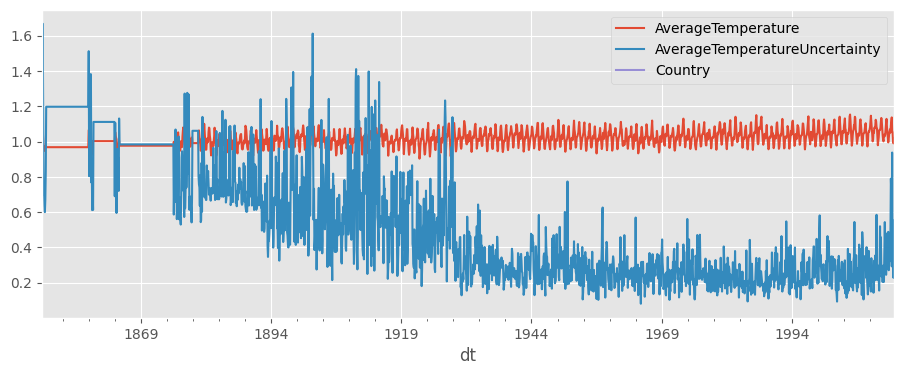

In [32]:
temps_df = temps_df.apply(pd.to_numeric, errors='coerce')
temps_df = temps_df.div(temps_df.iloc[0])
temps_df.plot()

In [ ]:
0799754630